## 1. A localized function in real space

Dada la función:

\begin{equation}
    f(x) =
    \begin{cases}
        1, & 3 < x < 4,\\
        0, & \text{otherwise},
    \end{cases}
\end{equation}

1. Sí, la función $f(x)$ es una función localizada en el intervalo $(3, 4)$.
2. No, debido a que $f(x)$ posee distontinuidades en los puntos $3$ y $4$.
3. La transformada de Fourier es una transformada integral que hace el cambio entre espacios mediante un *kernel* que depende del producto de los modos y las coordenadas, $\vec{k}\cdot\vec{x}$. En este caso, como solo estoy en una dimensión, entonces solo espero un modo de Fourier.
4. La integral va a soltar algunas costantes, en particular un $-i$. La magnitud puede va a variar dependiendo de cómo sea la definición de la transformada, pero va a ser constante, por lo tanto yo espero una línea recta horizontal en la parte negativa de las ordenadas.

![](./amplitud.png)

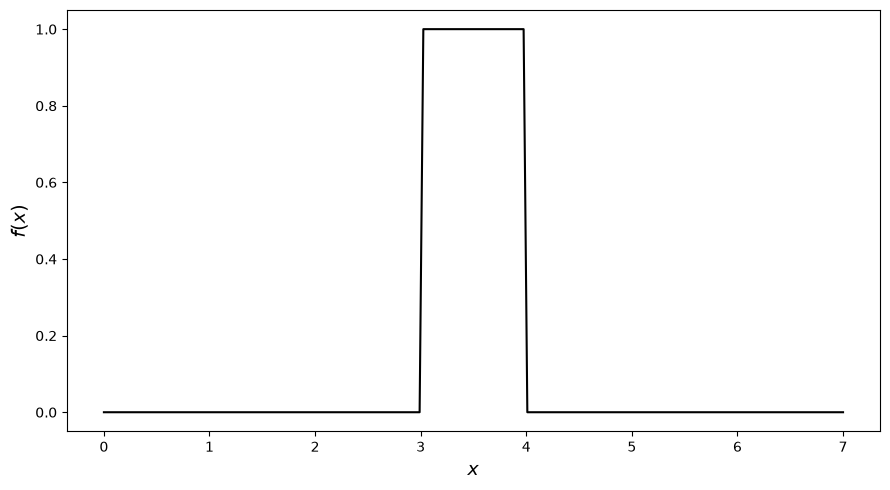

In [92]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, l = 3, r = 4):
    if l < x and x < r:
        return 1
    else:
        return 0

N = 200
L = 7
x_arr = np.linspace(0, L, N)
f_arr = np.array([f(x) for x in x_arr])

plt.figure(figsize=(9, 5))
plt.plot(x_arr, f_arr, "k-", lw=1.5, label=r"$f(x)$")
plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$f(x)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

## 2. From real to Fourier space

In [93]:
dx = L / (N - 1) # Hay N - 1 saltos desde x_arr[0] hasta x_arr[-1]
f_fourier_arr = np.fft.fft(f_arr)
k_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx) # La página de numpy.fft.fftfreq meciona que las unidades, pero no deja claro que hay que transformar al número de onda.

abs_k_arr = np.abs(k_arr)

k_min = np.min(abs_k_arr[abs_k_arr != 0])
k_min_index = np.argmax(abs_k_arr == k_min)

k_max = np.max(abs_k_arr)
k_max_index = np.argmax(abs_k_arr == k_max)

print(f"El espaciado entre modos es: {k_arr[1] - k_arr[0]:.4f}.")
print(f"La frecuencia mínima es: {k_min:.4f}, id: {k_min_index}.")
print(f"La frecuencia máxima es: {k_max:.4f}, id: {k_max_index}.")


El espaciado entre modos es: 0.8931.
La frecuencia mínima es: 0.8931, id: 1.
La frecuencia máxima es: 89.3110, id: 100.


1. <details><summary>Primero las positivas, luego las negativas.</summary> Si existen positivos y negativos, entonces deben existir determinados puntos donde se cruza el cero. Se puede analizar el signo de la primer entrada distinta de cero y encontrar todos aquellos cambios de signo con un único recorrido del <i>array</i> para obtener el orden de positivos y negativos. Resultando en que primero es positivo, luego toca el cero, continua positivo y, en algún momento, cruza el cero hacia los negativos.</details>
2. La frecuencia más pequeña disinta de cero es: $k = 0.1429$ y está en la posición $1$ del *array*.
3. La frecuencia más grande representada por el *grid* es: $|k| = 14.2857$ y está en la posición $100$ del *array*.
4. Quiero pensar que, al igual que $\Delta x$, $\Delta k$ representa el espaciado del *grid* elegido, en este caso representa el muestro de las frecuencias elegidas para representar a la función original con frecuencias de Fourier.
5. Determina el centro de la función y del espacio.


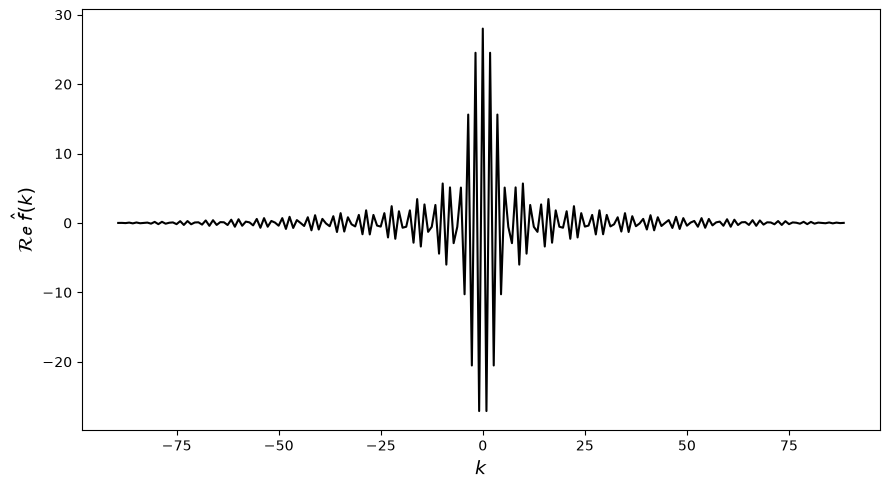

In [94]:
k_arr_shifted = np.fft.fftshift(k_arr)
f_fourier_arr_shifted = np.fft.fftshift(f_fourier_arr)

plt.figure(figsize=(9, 5))
plt.plot(k_arr_shifted, f_fourier_arr_shifted, "k-", lw=1.5, label=r"$Absolute$")
plt.xlabel(r"$k$", fontsize=14)
plt.ylabel(r"$\mathcal{Re}\ \hat f(k)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

## 3. The Fourier transform of a top-hat



/tmp/ipykernel_38797/1313912951.py:4: RuntimeWarning: invalid value encountered in divide
  return n / d


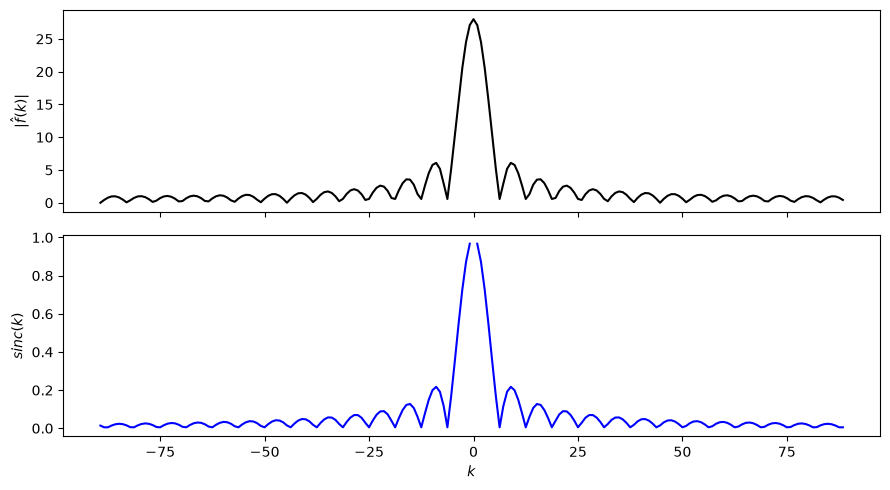

In [95]:
def sinc(k, D = 1):
    n = np.sin(k * D / 2)
    d = k * D / 2
    return n / d

envelop_arr = sinc(k_arr_shifted, 1) # Antes lo tenía en \Delta = 6 por  inspección, ahora entiendo que faltaba un 2\pi

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-", lw=1.5, label=r"$Fourier trans.$")
ax2.plot(k_arr_shifted, np.abs(envelop_arr), "b-", lw=1.5, label=r"$sinc-like envelope$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set(xlabel=r"$k$", ylabel=r"$sinc(k)$")
fig.tight_layout()
plt.show()

1. Sí, las oscilaciones sí se ven claramente.
2. Para representar las discontinuidades del *top-hat*, se necesitan altas frecuencias, estas nuevas frecuencias no necesariamente deben corresponder al dominio de la función original.
3. Lo que le ocurre es que los picos se van separado entre si y las amplitudes bajan. Si la transformada fuera una cuerda, el cambio debido al cambio del *top-hat* sería equivalente a tomar la cuerda por los extremos e irla estirando en direcciones opuestas.
4. Lo contrario, que los picos se acerquen más entre ellos y que las amplitudes crezcan.

## 4. Amplitude and phase



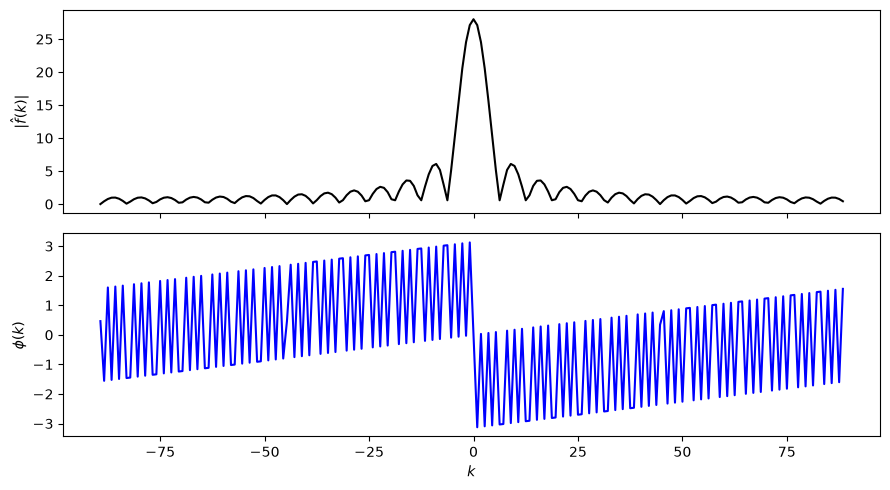

In [96]:
phase_arr = np.angle(f_fourier_arr_shifted)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-", lw=1.5, label=r"$Fourier trans.$")
ax2.plot(k_arr_shifted, phase_arr, "b-", lw=1.5, label=r"$Phase$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set(xlabel=r"$k$", ylabel=r"$\phi(k)$")
fig.tight_layout()
plt.show()

1. <details><summary>Las amplitudes no van a cambiar.</summary>Entendiendo la transformada de Fourier como el caso continuo de las series de Fourier, entonces cada $k$ representa una frecuencia de un armónico y se ocupan los mismo armónicos para representar la misma forma de las funciones, en este caso $f(x)$.</details>
2. Las frecuencias sí van a cambiar para cambiar el punto de inicio de la descripción.

Sea $f_{12}(x)$ la función $f(x)$ desplazada al intervalo $1 < f_{12}(x) < 2$ en el mismo dominio, entonces:

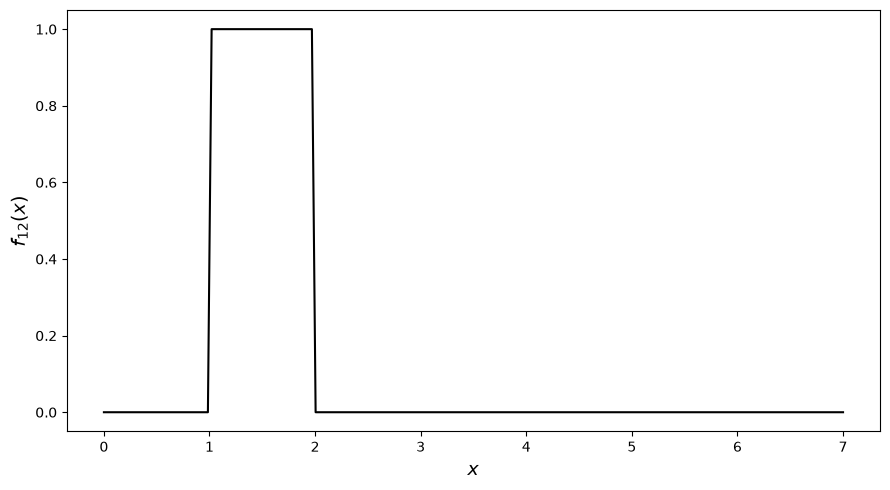

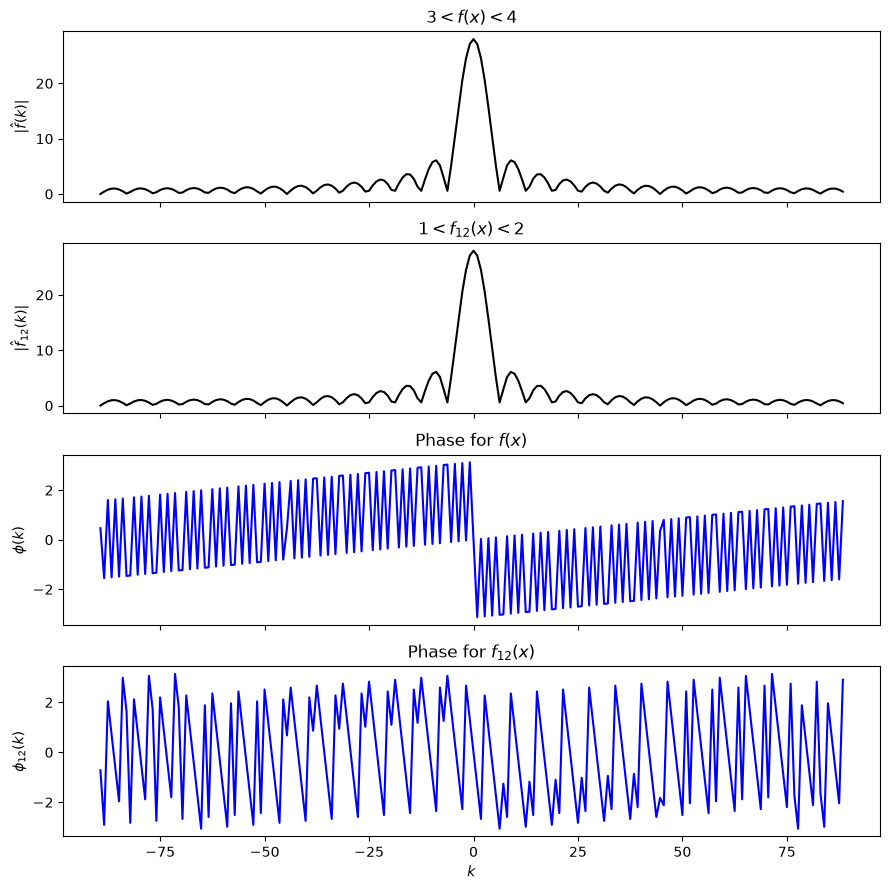

In [97]:
f12_arr = np.array([f(x, l=1, r=2) for x in x_arr])

plt.figure(figsize=(9, 5))
plt.plot(x_arr, f12_arr, "k-", lw=1.5, label=r"$f(x)$")
plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$f_{12}(x)$", fontsize=14)
#plt.legend()
plt.tight_layout()
plt.show()

k12_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx) # Se debe convertir también al número de onda con 2\pi
f12_fourier_arr = np.fft.fft(f12_arr)

k12_arr_shifted = np.fft.fftshift(k12_arr)
f12_fourier_arr_shifted = np.fft.fftshift(f12_fourier_arr)
phase12_arr = np.angle(f12_fourier_arr_shifted)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(9, 9))
ax1.plot(k_arr_shifted, np.abs(f_fourier_arr_shifted), "k-")
ax2.plot(k12_arr_shifted, np.abs(f12_fourier_arr_shifted), "k-")
ax3.plot(k_arr_shifted, phase_arr, "b-")
ax4.plot(k12_arr_shifted, phase12_arr, "b-")
ax1.set_title(r"$3 < f(x) < 4$")
ax2.set_title(r"$1 < f_{12}(x) < 2$")
ax3.set_title(r"Phase for $f(x)$")
ax4.set_title(r"Phase for $f_{12}(x)$")
ax1.set_ylabel(r"$|\hat f(k)|$")
ax2.set_ylabel(r"$|\hat f_{12}(k)|$")
ax3.set_ylabel(r"$\phi(k)$")
ax4.set(xlabel=r"$k$", ylabel=r"$\phi_{12}(k)$")
fig.tight_layout()
plt.show()

Puedo decir más acerca de las fases y es que, para la función original,en la distribución de fases se distinguen dos repeticiones de la misma estructura. Esto debe deberse a la simetría del sistema, pues 3.5 es el centro del dominio. Al mover el centro de la gráfica a 1.5, entonces la gráfica de fases que corresponde se ve también diferente.

## 5. Returning to real space

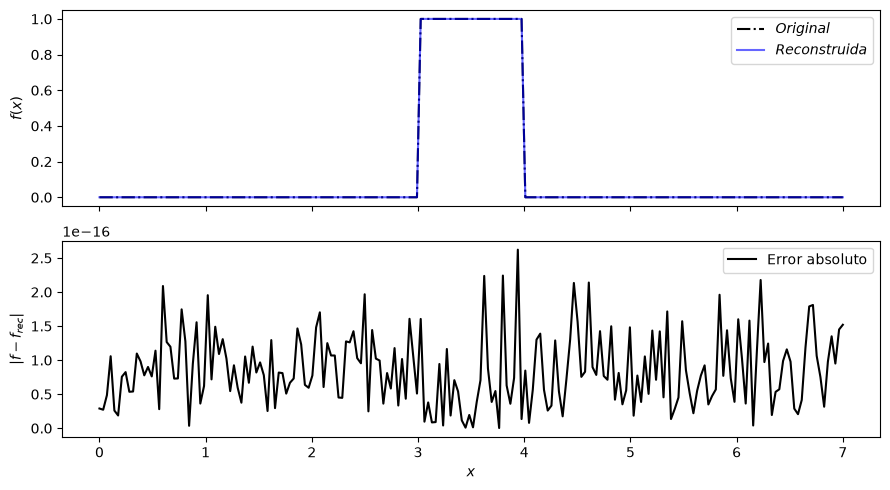

La parte imaginaria es ruido porque su máximo es: 2.09e-16


In [98]:
f_inv_fourier_arr = np.fft.ifft(f_fourier_arr)
err_arr = np.abs(f_arr - f_inv_fourier_arr)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
fig.subplots_adjust(hspace=0)
ax1.plot(x_arr, f_arr, "k-.", lw=1.5, label=r"$Original$")
ax1.plot(x_arr, f_inv_fourier_arr, "b-", alpha=0.6, lw=1.5, label=r"$Reconstruida$")
ax1.set_ylabel(r"$f(x)$")
ax1.legend()
ax2.plot(x_arr, err_arr, "k-", lw=1.5, label="Error absoluto")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$|f - f_{rec}|$")
ax2.legend()
fig.tight_layout()
plt.show()

print(f"La parte imaginaria es ruido porque su máximo es: {np.abs(f_inv_fourier_arr.imag).max():.2e}")

1. Sí, son la misma función debido a que el error absoluto máximo que se alcanza con la transformación es menor a $10^{-16}$.
2. Sí, contiene componentes imaginarias residuales.
3. Hay 16 ordenes de magnitud entre unas y otras, por lo que se puede decir que las componentes imaginarias son despreciables por ser ruido numérico.

## 6. The role of sampling

No es necesario copiar y pegar todo con distintos $N$, tampoco encapsular todo en una función para distintos $N$, con cambiar manualmente el valor e investigar tu comportamiento me parece que es suficiente.

### Predicciones:

1. No, no me espero que las frecuencias cambien por el mismo argumento que antes: las frecuencias determinan la forma, ante una modificación que no cambia la forma, no debe cambiar las frecuencias.
2. No, tampoco espero que cambie el dominio de las frecuencias.
3. Sí, la resolución sí debe cambiar, con un bajo $N$ espero ver trapezoides, con un alto $N$ espero ver un *top-hat* bien definido.

Dejando fijo $N$:

1. Quiero pensar que también se van a separar, pero de esto no estoy seguro.
2. Debe incrementar para ajustar al nuevo tamaño de la forma de la función.

### Resultados: 

1. Sí han cambiado las amplitudes.
2. También cambiaron las frecuencias máximas.
3. Sí, esto cambia porque se representan mejor las discontinuidades.

Dejando fijo $N$:

1. Sí, mientras más grande el intervalo, más pequeño el espaciado y viceversa.
2. La frecuencia mínima sí cambia y así debe ser porque el bin mínimo corresponde a la frecuencia mínima.

## 7. Fourier transform in two dimensions

![](./eye.png)

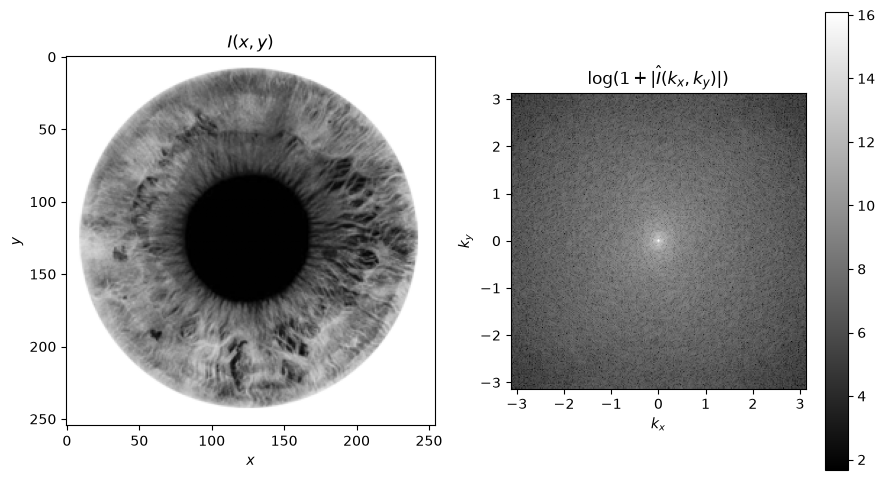

In [114]:
from PIL import Image

img = Image.open("eye.png") # Es un png que tiene problemas con el \alpha, por eso la compongo primero
bg = Image.new("RGBA", img.size, "white")
img = Image.alpha_composite(bg, img)

I_arr = np.asarray(img.convert("L"), dtype=float)
I_x_arr, I_y_arr = I_arr.shape

I_fourier_arr = np.fft.fft2(I_arr)
I_fourier_arr_shifted = np.fft.fftshift(I_fourier_arr)

k_x_arr = 2 * np.pi * np.fft.fftfreq(I_x_arr, d=1)
k_y_arr = 2 * np.pi * np.fft.fftfreq(I_y_arr, d=1)
k_x_arr_shifted = np.fft.fftshift(k_x_arr)
k_y_arr_shifted = np.fft.fftshift(k_y_arr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
ax1.imshow(I_arr, cmap="gray")
ax1.set(title=r"$I(x, y)$", xlabel=r"$x$", ylabel=r"$y$")
im = ax2.imshow(np.log(1 + np.abs(I_fourier_arr_shifted)), cmap="gray", origin="lower",
                extent=[k_x_arr_shifted[0], k_x_arr_shifted[-1], k_y_arr_shifted[0], k_y_arr_shifted[-1]])
ax2.set(title=r"$\log(1 + |\hat I(k_x, k_y)|)$", xlabel=r"$k_x$", ylabel=r"$k_y$")
fig.colorbar(im, ax=ax2)
fig.tight_layout()
plt.show()

1. <details><summary>Las frecuencias altas.</summary>Los detalles de la imagen real van a requerir más información de las frecuencias altas, es decir, longitudes de onda pequeñas, para contribuir a la recreación de la estructura a pequeña escala.</details>
2. Yo espero que aparezca en las frecuencias bajas/medias.

## 8. Filtering an Image

### 8.1. Low-pass filter

Yo me espero que, al quitarle todas las frecuencias por encima de cierto $k_0$, entonces se estará quitando fidelidad a la estrucutra a pequeña escala.

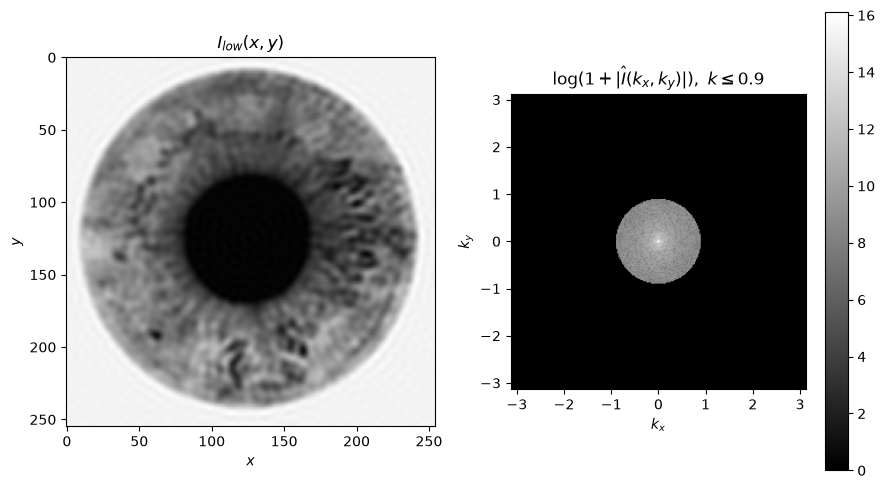

In [140]:
k0 = 0.9

X, Y = np.meshgrid(k_x_arr_shifted, k_y_arr_shifted)
k_mod_arr = np.hypot(X, Y)

I_lp_fourier_arr_shifted = np.where(k_mod_arr > k0, 0, I_fourier_arr_shifted) # Se anulan los modos con k > k0, k_mod_arr queda intacto
I_lp_arr = np.fft.ifft2(np.fft.ifftshift(I_lp_fourier_arr_shifted)).real

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
ax1.imshow(I_lp_arr, cmap="gray")
ax1.set(title=r"$I_{low}(x, y)$", xlabel=r"$x$", ylabel=r"$y$")
im = ax2.imshow(np.log(1 + np.abs(I_lp_fourier_arr_shifted)), cmap="gray", origin="lower",
                extent=[k_x_arr_shifted[0], k_x_arr_shifted[-1], k_y_arr_shifted[0], k_y_arr_shifted[-1]])
ax2.set(title=rf"$\log(1 + |\hat I(k_x, k_y)|),\ k \leq {k0}$", xlabel=r"$k_x$", ylabel=r"$k_y$")
fig.colorbar(im, ax=ax2)
fig.tight_layout()
plt.show()

1. Efectivamente, ha desaparecido la estructura a escalas pequeñas, es decir, han pedido fidelidad.
2. Se a vuelto más *pixela*: ha perdido nitidez.
3. Se han vuelto borrosos y ya no se distinguen todos los contornos correctamente.

### 8.2. High-pass filter

Me espero lo contrario, lo que yo quiero ver es que mi estructura  a gran escala desaparezca y vea las estructura a pequeña escala. Por ejemplo, el cículo negro del centro debería de desaparecer.

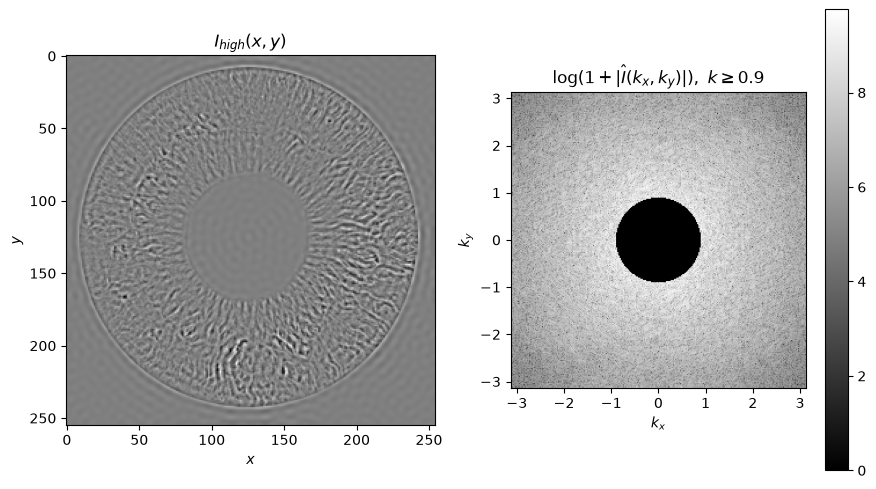

In [142]:
I_hp_fourier_arr_shifted = np.where(k_mod_arr < k0, 0, I_fourier_arr_shifted)
I_hp_arr = np.fft.ifft2(np.fft.ifftshift(I_hp_fourier_arr_shifted)).real

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
ax1.imshow(I_hp_arr, cmap="gray")
ax1.set(title=r"$I_{high}(x, y)$", xlabel=r"$x$", ylabel=r"$y$")
im = ax2.imshow(np.log(1 + np.abs(I_hp_fourier_arr_shifted)), cmap="gray", origin="lower",
                extent=[k_x_arr_shifted[0], k_x_arr_shifted[-1], k_y_arr_shifted[0], k_y_arr_shifted[-1]])
ax2.set(title=rf"$\log(1 + |\hat I(k_x, k_y)|),\ k \geq {k0}$", xlabel=r"$k_x$", ylabel=r"$k_y$")
fig.colorbar(im, ax=ax2)
fig.tight_layout()
plt.show()

1. Los contornos de la estructura a pequeña escala se nota mucho más, diciendonos que las grandes escalas han desaparecido.
2. Se ha homogeneizado, es decir, ahora las esquinas blanca y el centro negro se han vuelto del mismo color, lo que demuestra que ahora no se tiene información de esta estructura.
3. Aquellos contornos que representan a la estructura a muy pequeñas escalas. Las estrias del ojo se notan mucho más que el borde que delimita el círculo interno.

## 9. Design your own Fourier filter

1. Voy a crear un filtro que elimina todas las frecuencias, grandes o pequeñas, que caen sobre una banda recta de ancho $\Delta$, dirección $\theta \in [0, \pi)$ y cuya línea que la divida por la mitad longitudinalmente, $l$, pase por el origen. Es decir, dados $\Delta$ y $\theta$, la distancia más corta entre $l$ y los bordes de la banda serán $\Delta / 2$ y tendrán todas la misma dirección $\theta$.
2. Ya que estoy quitando todas las frecuencias de una dirección específica, espero que haya mucha menos fidelidad en la reproducción de la imagen original a la hora de hacer la transformación inversa en aquellas líneas pérpendiculares a la dirección $\theta$, pues no van a tener longitudes de onda que las describan. Incluso puede ue se pierda por completa cierta información.
3. Supongamos que quitamos todas las frecuencias en alguna de las diagonales de la imagen, entonces, como no ya no va a haber ondas que repliquen la estructura, debe perderse la información necesaria para distinguirla. Debe ser en pérpendicular porque la frecuencia es transversal a la propagación de la onda.

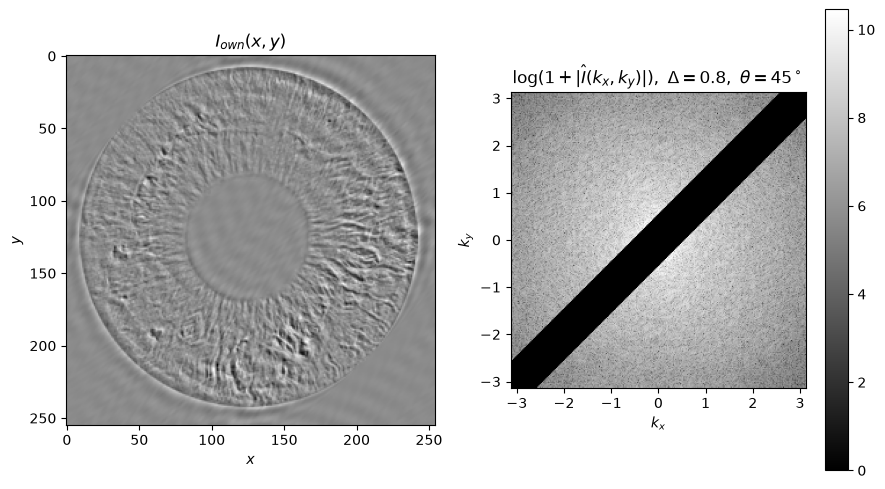

In [152]:
Del = 0.8
theta = np.pi / 4

condition = np.abs(Y * np.cos(theta) - X * np.sin(theta)) < Del / 2
I_own_fourier_arr_shifted = np.where(condition, 0, I_fourier_arr_shifted)
I_own_arr = np.fft.ifft2(np.fft.ifftshift(I_own_fourier_arr_shifted)).real

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
ax1.imshow(I_own_arr, cmap="gray")
ax1.set(title=r"$I_{own}(x, y)$", xlabel=r"$x$", ylabel=r"$y$")
im = ax2.imshow(np.log(1 + np.abs(I_own_fourier_arr_shifted)), cmap="gray", origin="lower",
                extent=[k_x_arr_shifted[0], k_x_arr_shifted[-1], k_y_arr_shifted[0], k_y_arr_shifted[-1]])
ax2.set(title=rf"$\log(1 + |\hat I(k_x, k_y)|),\ \Delta = {Del},\ \theta = {np.degrees(theta):.0f}^\circ$", xlabel=r"$k_x$", ylabel=r"$k_y$")
fig.colorbar(im, ax=ax2)
fig.tight_layout()
plt.show()

Estoy sorprendido porque he predicho correctamente el comportamiento de la dirección. En el ejemplo que muestro con $\Delta = 0.8$ y $\theta = \pi / 4$ se puede ver que la información de los contornos de una línea en diagonal opuesta  a la banda removida se perdió, pero no he predicho que, al tener una banda lo suficientemente ancha que pasa por el origen, entonces también ha desaparecido la información de gran parte de la estructura a gran escala.

## 10. What have we learned?

1. Los valores pequeños $|k|$ representan a la estructura a gran escala.
2. Los valores grandes de $|k|$ representan a la estructura a pequeña escala.
3. Las fases de la transformada van a cambiar, pero sus amplitudes no.
4. La menor frecuencia no cero determina el tamaño del *grid* $\Delta k$ del espacio de Fourier.
5. El nivel de resolución de la estructura en espacio real determina la máxima frecuencia que se puede determinar, más resolución implica menor amplitud y viceversa.
6. No, no se tiene suficiente información para reconstruir la información original porque la amplitudes reconstruyen la estructura, pero las fases la colocan en el lugar correcto.

## 11. AI.use statement

Durante gran parte de mi día a día utilizo la AI como una especia de "superwikipedia", de modo que no salgo a internet para preguntar cosas que la AI puede buscar en mi lugar y mucho más rápido. Esto se puede ver reflejado en mi historial de *opencode* [FALTA COLOCAR LINK], al igual que lo hice en la práctica pasada. La utilizo sobre todo porque no quiero leer la documentación de, por ejemplo, `PIL.Image`, como se hacia antes, si no que quiero avanzar en la física y el entendimiento de los métodos.

Utilizo, por costumbre, *opencode* desde la terminal, pero esta vez estoy probando *claude code* desde *VS Code* por comodidad y por novedad. He descubierto que voy mucho más rápido de esta forma y que puedo saltarme cosas que, de hacerlo a la vieja escuela, me hubiera tomado algunos cuantos minutos que, acumulados, pueden volver fácilmente horas de estudio de *python*. A partir de la sección 6 he utilizado este método y sí he pedido que se escriban cosas repetitivas como gráficas. Un caso particular es `condition`, una única línea de código que tenía en mi cabeza, que pude haber hecho con trigonometria, pero que la AI ha hecho en unos pocos segundo de la forma más optima posible (no sé cuánto tiempo me hubiera tomado idear utilizar la fórmula del punto y la recta). Este paso lo revisé manualmente, tanto para poder explicarlo como para estar seguro de que funciona.

He agregado mi sesión de *Claude* como un `.txt` por si se desea explorar.